In [ ]:
!pip install gymnasium


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time




In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=False)

# Fix randomness
np.random.seed(42)

# Create environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# Seed environment
env.reset(seed=42)
env.action_space.seed(42)

print("States:", env.observation_space.n)
print("Actions:", env.action_space.n)


States: 16
Actions: 4


In [ ]:
Q = np.zeros((env.observation_space.n, env.action_space.n))
Q


array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
def qlearn(env, episodes=2000, alpha=0.6, gamma=0.9, epsilon=0.9, decay=0.003):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = []

    state, _ = env.reset(seed=42)

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total = 0

        while not done:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.random.choice(np.flatnonzero(Q[state] == Q[state].max()))

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if done:
                target = reward
            else:
                target = reward + gamma * np.max(Q[next_state])

            Q[state, action] += alpha * (target - Q[state, action])

            state = next_state
            total += reward

        epsilon = max(0.05, epsilon*np.exp(-decay))
        rewards.append(total)

    return Q, rewards

In [ ]:
Q1, rewards1 = qlearn(env)
print(Q1)


[[0.531441   0.59049    0.59049    0.531441  ]
 [0.3188646  0.         0.6561     0.57790509]
 [0.55269864 0.729      0.         0.39366   ]
 [0.         0.         0.         0.        ]
 [0.59049    0.6561     0.         0.531441  ]
 [0.         0.         0.         0.        ]
 [0.         0.81       0.         0.64745109]
 [0.         0.         0.         0.        ]
 [0.6561     0.         0.729      0.59049   ]
 [0.6561     0.6561     0.81       0.        ]
 [0.729      0.9        0.         0.729     ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.6488075  0.863136   0.729     ]
 [0.6986736  0.9        1.         0.81      ]
 [0.         0.         0.         0.        ]]


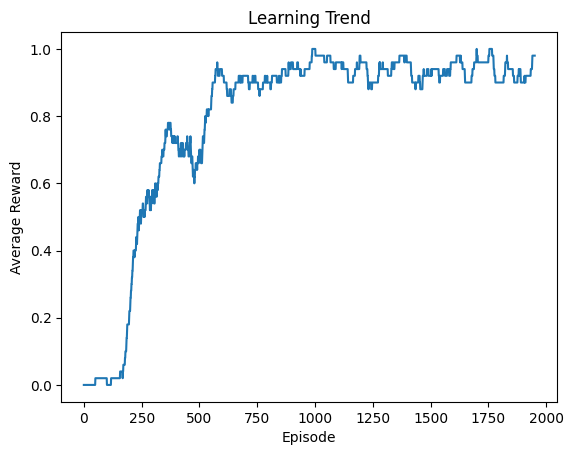

In [ ]:
def moving_avg(data, w=50):
    return np.convolve(data, np.ones(w)/w, mode='valid')

plt.plot(moving_avg(rewards1))
plt.title("Learning Trend")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.show()

In [ ]:
demo_map = [
"SFFFF",
"FHFHF",
"FFFFF",
"FHFHF",
"FFFFG"
]

env2 = gym.make("FrozenLake-v1", desc=demo_map, is_slippery=False)
Q2, rewards2 = qlearn(env2, episodes=2000)
print(Q2.shape)

(25, 4)


In [ ]:
def qlearn_shaped(env, episodes=2500, alpha=0.6, gamma=0.9, epsilon=1.0):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards=[]

    state, _ = env.reset(seed=42)

    for ep in range(episodes):
        state,_ = env.reset()
        done=False
        total=0

        while not done:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.random.choice(np.flatnonzero(Q[state] == Q[state].max()))

            next_state,reward,terminated,truncated,_ = env.step(action)
            done = terminated or truncated

            # Example shaping values (different from assignment)
            if reward == 1:
                reward = 2
            elif terminated and reward == 0:
                reward = -0.5
            else:
                reward = -0.02

            if done:
                target = reward  # Uses your shaped reward (2 or -0.5)
            else:
                target = reward + gamma * np.max(Q[next_state]) # Uses -0.02 + future estimate

            Q[state, action] += alpha * (target - Q[state, action])

            state = next_state
            total += reward

        epsilon = max(0.05, epsilon*0.997)
        rewards.append(total)

    return Q,rewards

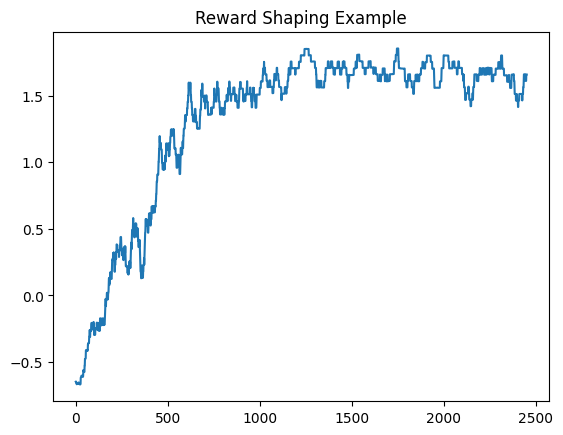

In [ ]:
Q3, rewards3 = qlearn_shaped(env2)
plt.plot(moving_avg(rewards3))
plt.title("Reward Shaping Example")
plt.show()

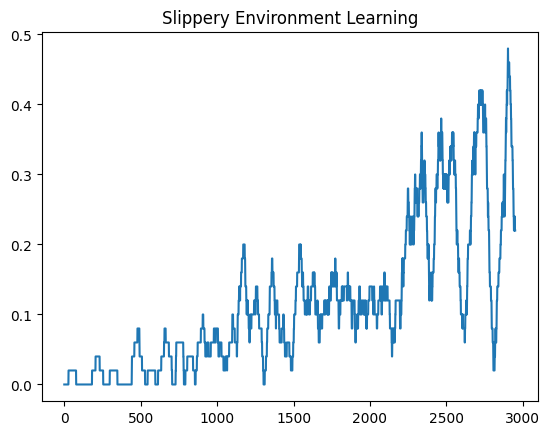

In [ ]:
env3 = gym.make("FrozenLake-v1", is_slippery=True)
Q4, rewards4 = qlearn(env3, episodes=3000, decay=0.001)
plt.plot(moving_avg(rewards4))
plt.title("Slippery Environment Learning")
plt.show()

In [ ]:
state, _ = env.reset(seed=42)

def test_agent(env, Q, runs=10):
    for r in range(runs):
        state, _ = env.reset()
        done = False
        steps = 0

        while not done:
            action = np.random.choice(np.flatnonzero(Q[state] == Q[state].max()))
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1

        if reward == 1:
            print(f"Run {r+1}: Reached Goal in {steps} steps")
        else:
            print(f"Run {r+1}: Failed after {steps} steps")

test_agent(env, Q1)


Run 1: Reached Goal in 6 steps
Run 2: Reached Goal in 6 steps
Run 3: Reached Goal in 6 steps
Run 4: Reached Goal in 6 steps
Run 5: Reached Goal in 6 steps
Run 6: Reached Goal in 6 steps
Run 7: Reached Goal in 6 steps
Run 8: Reached Goal in 6 steps
Run 9: Reached Goal in 6 steps
Run 10: Reached Goal in 6 steps


In [ ]:
def sarsa(env, episodes=1500, alpha=0.6, gamma=0.9, epsilon=0.9):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = []

    state, _ = env.reset(seed=42)

    for ep in range(episodes):
        state, _ = env.reset()

        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.random.choice(np.flatnonzero(Q[state] == Q[state].max()))

        done = False
        total = 0

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if np.random.rand() < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = np.random.choice(np.flatnonzero(Q[next_state] == Q[next_state].max()))

            if done:
                target = reward
            else:
                target = reward + gamma * Q[next_state, next_action]

            Q[state, action] += alpha * (target - Q[state, action])

            state = next_state
            action = next_action
            total += reward

        epsilon = max(0.05, epsilon * 0.997)
        rewards.append(total)

    return Q, rewards


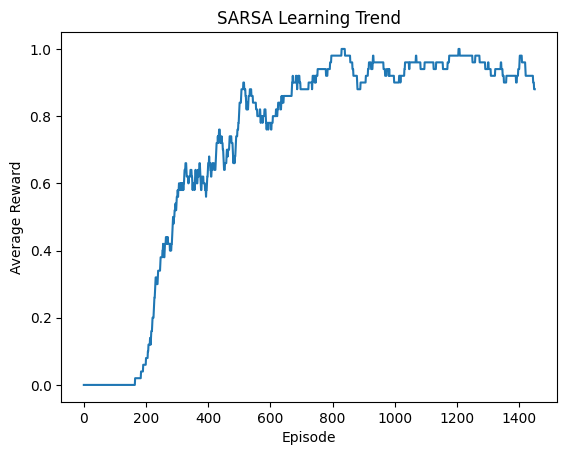

In [ ]:
Q_sarsa, rewards_sarsa = sarsa(env)
plt.plot(moving_avg(rewards_sarsa))
plt.title("SARSA Learning Trend")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.show()

In [ ]:
def watch_trained_agent(q_table, agent_name="Agent", env_name="FrozenLake-v1", is_slippery=False, desc=None):
    # Added the agent's name to the print statement
    print(f"\nLet's watch the trained agent: === {agent_name} ===")

    if desc is not None:
        eval_env = gym.make(env_name, desc=desc, is_slippery=is_slippery, render_mode="human")
    else:
        eval_env = gym.make(env_name, is_slippery=is_slippery, render_mode="human")

    state, info = eval_env.reset()
    done = False
    step_count = 0

    while not done:
        action = np.random.choice(np.flatnonzero(q_table[state] == q_table[state].max()))
        state, reward, terminated, truncated, info = eval_env.step(action)
        done = terminated or truncated
        step_count += 1
        time.sleep(1)

    if reward == 1.0:
        print(f"[{agent_name}] Goal reached in {step_count} steps! 🏆")
    else:
        print(f"[{agent_name}] Agent fell in a hole or ran out of time after {step_count} steps. 💥")

    eval_env.close()

# Now we pass a descriptive name for each agent we watch
watch_trained_agent(Q1, agent_name="Q1 (Q-Learning Default 4x4)", is_slippery=False)
watch_trained_agent(Q2, agent_name="Q2 (Q-Learning Custom 5x5)", is_slippery=False, desc=demo_map)
watch_trained_agent(Q3, agent_name="Q3 (Shaped Rewards 5x5)", is_slippery=False, desc=demo_map)
watch_trained_agent(Q4, agent_name="Q4 (Q-Learning Slippery 4x4)", is_slippery=True)
watch_trained_agent(Q_sarsa, agent_name="Q_sarsa (SARSA Default 4x4)", is_slippery=False)


Let's watch the trained agent: === Q1 (Q-Learning Default 4x4) ===
[Q1 (Q-Learning Default 4x4)] Goal reached in 6 steps! 🏆

Let's watch the trained agent: === Q2 (Q-Learning Custom 5x5) ===
[Q2 (Q-Learning Custom 5x5)] Goal reached in 8 steps! 🏆

Let's watch the trained agent: === Q3 (Shaped Rewards 5x5) ===
[Q3 (Shaped Rewards 5x5)] Goal reached in 8 steps! 🏆

Let's watch the trained agent: === Q4 (Q-Learning Slippery 4x4) ===
[Q4 (Q-Learning Slippery 4x4)] Agent fell in a hole or ran out of time after 12 steps. 💥

Let's watch the trained agent: === Q_sarsa (SARSA Default 4x4) ===
[Q_sarsa (SARSA Default 4x4)] Goal reached in 6 steps! 🏆
